In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import warnings

# Configurações de visualização
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set_palette("viridis")
sns.set_style("whitegrid")

# Função para estilizar tabelas
def estilizar_tabela(df):
    return df.style.background_gradient(cmap='Blues')\
             .set_properties(**{'text-align': 'center', 'font-family': 'Arial'})\
             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#404040'), ('color', 'white')]}])

#📌 Extracão

In [ ]:
# --- SIMULAÇÃO DE COLETA DE DADOS VIA API ---

arquivo_json = 'TelecomX_Data.json'

try:
    with open(arquivo_json, 'r', encoding='utf-8') as f:
        dados_brutos = json.load(f)
    
    # Normalização: JSON aninhado em uma tabela plana
    df = pd.json_normalize(dados_brutos)
    
    print("✅ Dados carregados com sucesso!")
    print(f"Dimensões iniciais: {df.shape[0]} linhas e {df.shape[1]} colunas.")
    
except FileNotFoundError:
    print(f"❌ Erro: O arquivo '{arquivo_json}' não foi encontrado.")

df.head()

✅ Dados carregados com sucesso!
Dimensões iniciais: 7267 linhas e 21 colunas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [ ]:
# --- RENOMEAR COLUNAS ---
colunas_limpas = {}
for col in df.columns:
    # Coluna de cobrança, manter o 'Charges.' para identificar melhor
    if 'Charges' in col:
        colunas_limpas[col] = col.split('account.')[-1] 
    else:
        # Pegamos apenas o último nome
        colunas_limpas[col] = col.split('.')[-1]

df.rename(columns=colunas_limpas, inplace=True)

# --- TRATAMENTO DE DADOS INCONSISTENTES ---

# 1. Tratando a coluna 'Churn'
# Identificar valores vazios que não servem para treino/análise
df_clean = df[df['Churn'] != ''].copy()

# 2. Tratando a coluna 'Charges.Total'
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# Preenchendo valores nulos
df_clean['Charges.Total'].fillna(0, inplace=True)

# --- PADRONIZAÇÃO E TRADUÇÃO ---
mapa_colunas = {
    'customerID': 'ID_Cliente',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefonico',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Cobranca_Mensal',
    'Charges.Total': 'Cobranca_Total',
    'Churn': 'Churn'
}

df_clean.rename(columns=mapa_colunas, inplace=True)

# Traduzindo valores categóricos (Sim/Não, Masculino/Feminino)
mapa_valores = {'Yes': 'Sim', 'No': 'Não', 'Male': 'Masculino', 'Female': 'Feminino'}
for col in df_clean.select_dtypes(include='object').columns:
    if col != 'ID_Cliente': 
        df_clean[col] = df_clean[col].replace(mapa_valores)

# Ajustando a coluna Idoso para ser categórica também
df_clean['Idoso'] = df_clean['Idoso'].map({0: 'Não', 1: 'Sim'})

# --- CRIAÇÃO DE NOVAS FEATURES ---
# Criando a coluna 'Contas_Diarias'
df_clean['Contas_Diarias'] = round(df_clean['Cobranca_Mensal'] / 30, 2)

print("✅ Limpeza e Transformação concluídas com sucesso!")

estilizar_tabela(df_clean.head())

✅ Limpeza e Transformação concluídas com sucesso!


,ID_Cliente,Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Multiplas_Linhas,Servico_Internet,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0002-ORFBO,Não,Feminino,Não,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,One year,Sim,Mailed check,65.600000,593.300000,2.190000
1,0003-MKNFE,Não,Masculino,Não,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Month-to-month,Não,Mailed check,59.900000,542.400000,2.000000
2,0004-TLHLJ,Sim,Masculino,Não,Não,Não,4,Sim,Não,Fiber optic,Não,Não,Sim,Não,Não,Não,Month-to-month,Sim,Electronic check,73.900000,280.850000,2.460000
3,0011-IGKFF,Sim,Masculino,Sim,Sim,Não,13,Sim,Não,Fiber optic,Não,Sim,Sim,Não,Sim,Sim,Month-to-month,Sim,Electronic check,98.000000,1237.850000,3.270000
4,0013-EXCHZ,Sim,Feminino,Sim,Sim,Não,3,Sim,Não,Fiber optic,Não,Não,Não,Sim,Sim,Não,Month-to-month,Sim,Mailed check,83.900000,267.400000,2.800000


#📊 Carga e análise

In [ ]:
# Resumo estatístico das variáveis numéricas
display(df_clean.describe().T)

# Verificar a distribuição do Churn 
churn_counts = df_clean['Churn'].value_counts()
fig = px.pie(values=churn_counts, names=churn_counts.index, title='Distribuição de Churn (Evasão)',
             color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

,count,mean,std,min,25%,50%,75%,max
Meses_Contrato,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
Cobranca_Mensal,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Cobranca_Total,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
Contas_Diarias,7043.0,2.158675,1.003088,0.61,1.18,2.34,2.99,3.96


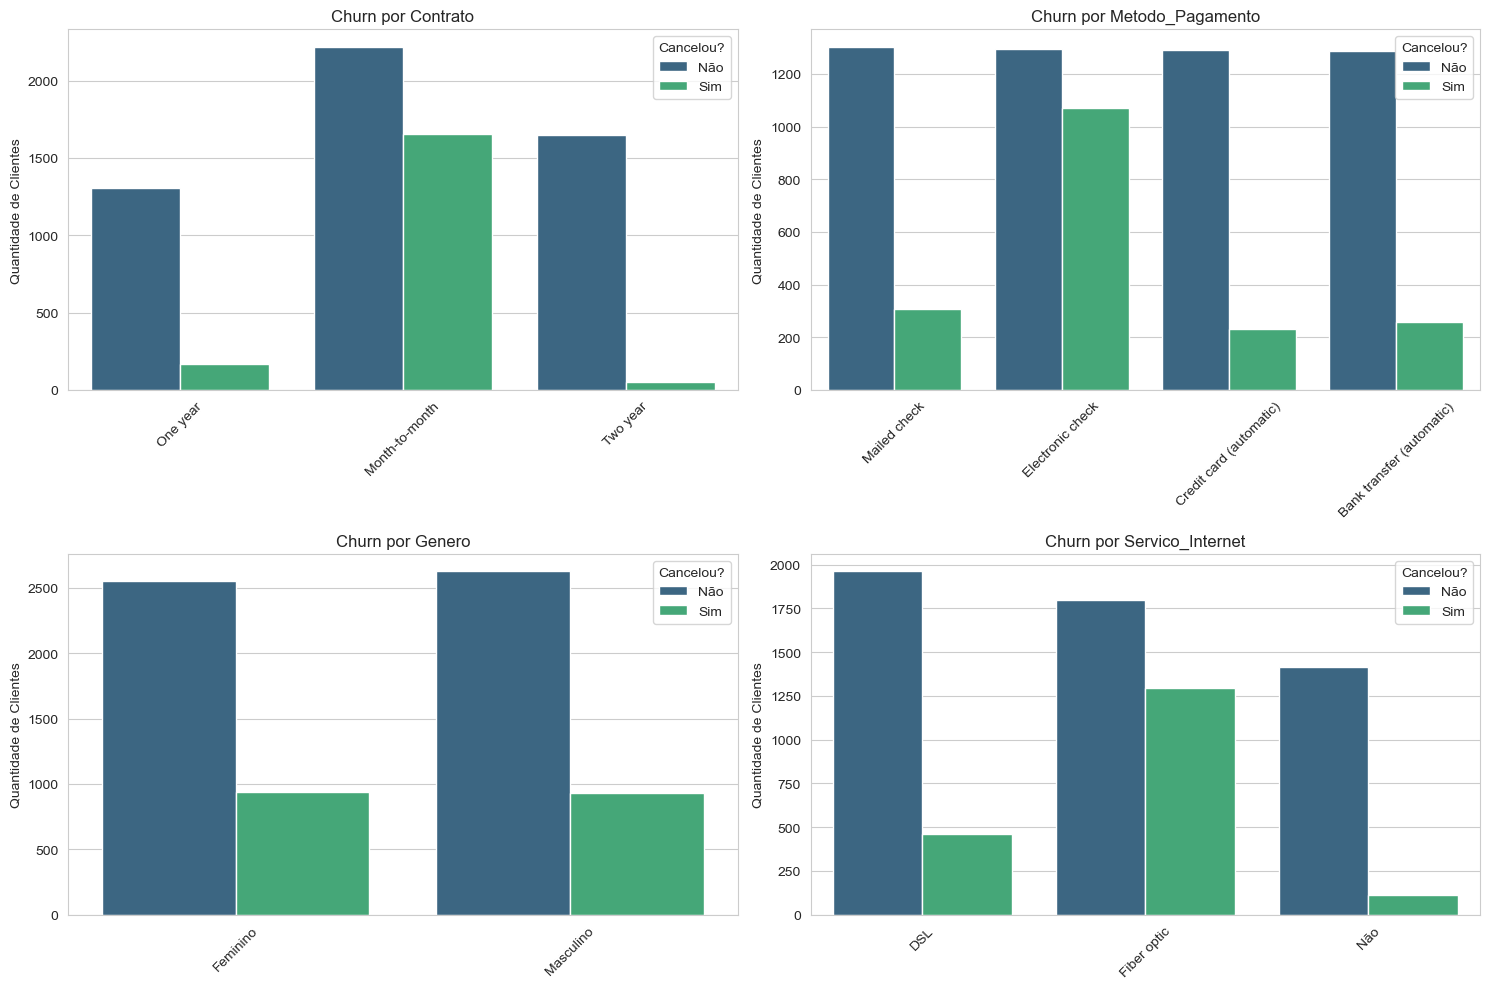

In [14]:
cols_categoricas = ['Contrato', 'Metodo_Pagamento', 'Genero', 'Servico_Internet']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_categoricas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df_clean, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn por {col}')
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.ylabel('Quantidade de Clientes')
    plt.legend(title='Cancelou?')

plt.tight_layout()
plt.show()

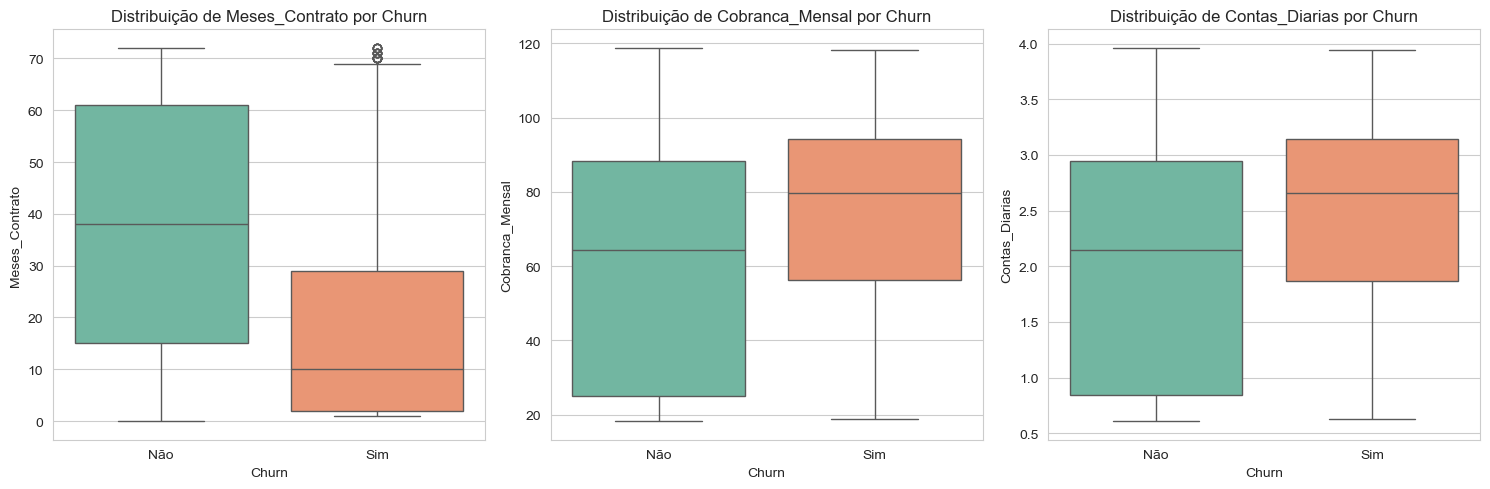

In [15]:
cols_numericas = ['Meses_Contrato', 'Cobranca_Mensal', 'Contas_Diarias']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df_clean, x='Churn', y=col, palette='Set2')
    plt.title(f'Distribuição de {col} por Churn')

plt.tight_layout()
plt.show()

Correlação 


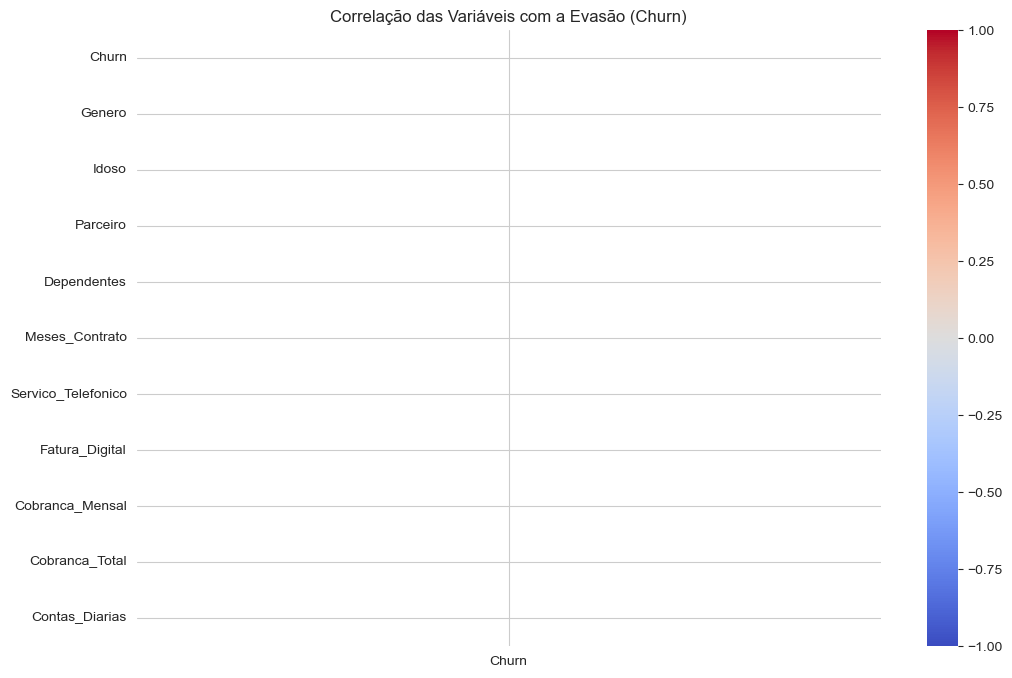

In [ ]:
# Preparando dados para correlação 
df_corr = df_clean.copy()

# Mapeamento binário
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        if set(df_corr[col].unique()).issubset({'Sim', 'Não'}):
            df_corr[col] = df_corr[col].map({'Sim': 1, 'Não': 0})
        elif set(df_corr[col].unique()).issubset({'Masculino', 'Feminino'}):
            df_corr[col] = df_corr[col].map({'Masculino': 1, 'Feminino': 0})

# Convertendo a coluna Alvo Churn para correlação
df_corr['Churn'] = df_corr['Churn'].map({'Sim': 1, 'Não': 0})

# Filtrar apenas colunas numéricas para a matriz
matriz_corr = df_corr.select_dtypes(include=[np.number]).corr()

# Plotando o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr[['Churn']].sort_values(by='Churn', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Variáveis com a Evasão (Churn)')
plt.show()

#📄Relatorio Final

Relatório de Análise de Evasão (Churn) - Telecom X

1. Introdução O objetivo deste projeto foi identificar padrões no comportamento dos clientes que levam ao cancelamento (Churn). Analisei dados demográficos, serviços contratados e informações financeiras.

2. Tratamento de Dados Os dados foram extraídos via JSON. Realizei a limpeza removendo 224 registros sem informação de Churn e tratei 11 registros com valores financeiros vazios. Criei a variável Contas_Diarias para refinar a análise de gastos.

3. Principais Conclusões

Contratos: Clientes com contratos mês a mês apresentam a maior taxa de evasão.

Pagamento: O método Cheque Eletrônico tem forte correlação positiva com o cancelamento.

Fidelidade: Clientes novos são os mais propensos a sair. A evasão diminui drasticamente conforme o tempo de contrato aumenta.

Serviços: Usuários de Fibra Óptica tendem a cancelar mais do que usuários de DSL, sugerindo possível insatisfação com preço ou serviço técnico deste produto específico.

4. Recomendações

Incentivar a migração de contratos mensais para anuais oferecendo descontos.

Investigar a qualidade técnica e o suporte para clientes de Fibra Óptica.

Implementar um programa de onboarding focado nos primeiros 6 meses do cliente, onde o risco de saída é maior.